<a href="https://colab.research.google.com/github/zoetice/data-science/blob/main/Copy_of_Unit8ExercisesSF.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Unit 8 Exercises: The Art of BART

These exercises are grouped into two parts:

- Questions on the nature of decision trees, random forests, and BART models
- An oppurtunity to practice implementing and analyzing a BART model.

Enjoy!

## Bartian Theory

**Task1**:

Draw a decision tree--on a physical piece of paper--that predicts how many calories you burn in a day, using time you spent exercising that day (in minutes) as a predictor.

To help you understand what you're doing with this tree, seperately create an x/y plot with time exercising as x, and calories burned as y.

If this seems to easy, then add another variable or two (type of exercise?), and/or increase the depth of your tree.

You do not have to show me or turn in your tree to earn credit for this question, although I would like to see your drawing.

**Task2**:

What is a decision tree? How do they work?

"Think of decision trees as flow charts, but with several restrictions.

Each node can have only one 'parent' node, but many children.
Binary decision trees, where each node has one parent, and two or zero children.
There is a special node called the 'root' node, with no parents.
Each layer of the tree sorts the predictor values into subsets of the predicted values." - Unit 8 Notes

**Task3**:

What does the "depth" of a decision tree mean?

How do I know if a tree is too deep, or not deep enough?

The depth is how many layers the tree has. More layers can capture more patterns in the data but some data doesn't need as many layers. Too many or not enough depth and overfit and underfit the data.

**Task4:**

How are BART models similar and different from a decision tree?

"In addition to the randomized root nodes of a a basic RF, BART builds its trees in a sort of sequential manner. BART actually starts with all the trees it needs, but then randomly alters each tree based on the other trees. The "based on the other trees" bit ensures that BART is encouraging the growth of different trees"

"it selects each change to one of its trees as part of an MCMC. This ensures that the whole BART model is a sample from some posterior distribution of possible random forests"

"BART puts regularizing priors on the depth of each decision tree, and on the magnitude of the leaf nodes"

- Unit 8 notes

**Task5**:

Why would we use a BART model instead of a decision tree?

"The priors over the depth helps ensure that all the trees will be shallow, that the depth will be much less than the number of data points. Priors on the leaf nodes ensures that our model only explores near the actual data; the leaf node priors are more traditional regularizing priors... BART-like models seem to perform much better than anything else at causal inference problems" - Unit 8

## Bartian Penguins

**Task6**:

Create a BART model that uses flipper length, bill depth, and bill length to predict body mass in penguins, and make a ppc to check its fit

Code for loading the data is below. You'll need to do everything else yourself.

Remember to use my notes as a reference, and to copy and paste from them when it makes sense to.

Oh, and try a normal likelihood.

In [2]:
import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc as pm
import seaborn as sns
import graphviz as gv

In [ ]:
!pip install pymc-bart
import pymc_bart as pmb

In [ ]:
#drop the incomplete rows from the data
url="https://raw.githubusercontent.com/thedarredondo/data-science-fundamentals/main/Data/penguins.csv"
penguins = pd.read_csv(url).dropna()

In [ ]:
with pm.Model() as model_penguins:
    X = penguins[['flipper_length', 'bill_depth', 'bill_length']].values
    Y = penguins['body_mass'].values

    # Use HalfNormal for standard deviation for better inference
    s = pm.HalfNormal('s', 100)

    # BART now directly models the mean of Y
    μ = pmb.BART("μ", X, Y, m=50)

    # Use Normal likelihood as requested
    y = pm.Normal("y", mu=μ, sigma=s, observed=Y)
    idata_penguins = pm.sample(compute_convergence_checks=False)

In [ ]:
pm.sample_posterior_predictive(idata_penguins,model_penguins, extend_inferencedata=True)

<Axes: xlabel='y'>

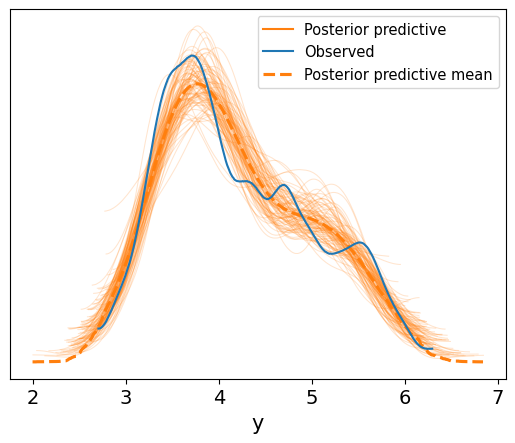

In [ ]:
az.plot_ppc(idata_penguins, num_pp_samples=100, colors=["C1", "C0", "C1"])

In [ ]:
posterior_mean = idata_penguins.posterior["μ"]

μ_hdi = az.hdi(ary=idata_penguins, group="posterior", var_names=["μ"], hdi_prob=0.74)

pps = az.extract(
    idata_penguins, group="posterior_predictive", var_names=["y"]
).T

**Task7**:

Plot flipper length versus body mass,

and then plot the posterior predictve from the model over the data.
You're going to copy paste the plotting code from the notes, fyi.

/usr/local/lib/python3.12/dist-packages/arviz/plots/hdiplot.py:166: FutureWarning: hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence with other functions
  hdi_data = hdi(y, hdi_prob=hdi_prob, circular=circular, multimodal=False, **hdi_kwargs)


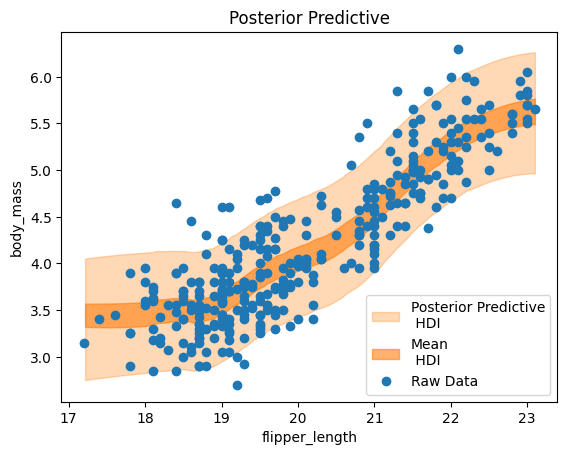

In [ ]:
idx = np.argsort(X[:, 0])
fig, ax = plt.subplots()

az.plot_hdi(
    x=X[:, 0],
    y=pps,
    ax=ax,
    hdi_prob=0.93,
    fill_kwargs={"alpha": 0.3, "label": "Posterior Predictive\n HDI"},
)

az.plot_hdi(
    x=X[:, 0],
    y=posterior_mean,
    ax=ax,
    hdi_prob=0.74,
    fill_kwargs={"alpha": 0.6, "label": "Mean\n HDI"},
)
ax.plot(X[:, 0], Y, "o", c="C0", label="Raw Data")
ax.legend(loc="lower right")
ax.set(
    title="Posterior Predictive",
    xlabel="flipper_length",
    ylabel="body_mass",
);

**Task8**:

Interpret the plot above in context. Do you think it captures the true association between flipper length and body mass in penguins? Why or why not? Make sure to reference specific things you see in the plot.

The plot shows a positive relationship between flipper length and body mass which makes sense. I think this model works well as it covers most of the raw data points. The plot indicates that the BART model has effectively learned the relationship between flipper length and body mass, showing a clear positive correlation while also accounting for the uncertainty in the predictions.

**Task9**:

Create partial depnedence plots (pdps), individual conditional expectation (ice) plots, and a variable importance plot for the BARTpenguin model.

In [ ]:


import pandas as pd
import pymc as pm
import pymc_bart as pmb
import numpy as np
import arviz as az
import matplotlib.pyplot as plt # Import matplotlib for plotting

# Load data (from WHwxrrVlyKgz)
url="https://raw.githubusercontent.com/thedarredondo/data-science-fundamentals/main/Data/penguins.csv"
penguins = pd.read_csv(url).dropna()

# Define X and Y (from nCo6vjqmMrUj)
X = penguins[['flipper_length', 'bill_depth', 'bill_length']].values
Y = penguins['body_mass'].values

# Define the BART model and sample (from nCo6vjqmMrUj)
with pm.Model() as model_penguins:
    s = pm.HalfNormal('s', 100)
    # The BART random variable itself, not its posterior samples
    μ = pmb.BART("μ", X, Y, m=50)
    y = pm.Normal("y", mu=μ, sigma=s, observed=Y)
    idata_penguins = pm.sample(compute_convergence_checks=False)

# posterior_mean is defined correctly for other uses, but plot_pdp needs the BART RV (μ)
posterior_mean = idata_penguins.posterior["μ"]


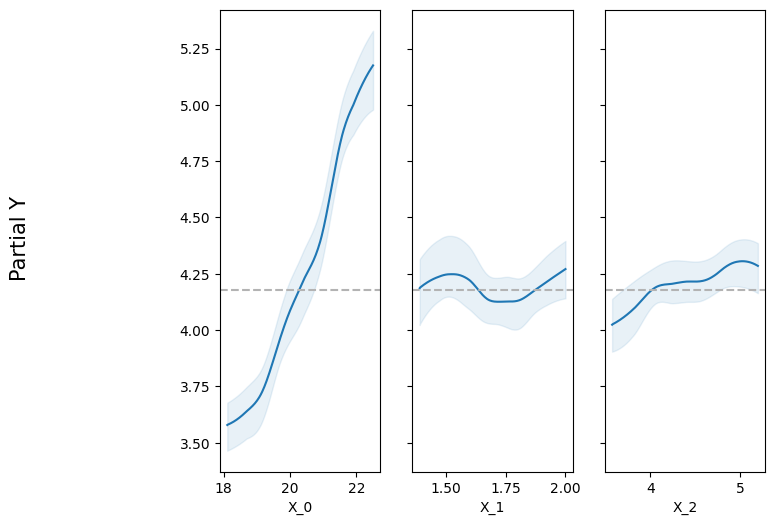

In [13]:
# Original code for plotting - corrected to use μ and removed func=np.exp
pmb.plot_pdp(μ, X, Y, grid=(1, 5), figsize = (12,6))
plt.show()

array([<Axes: xlabel='X_0'>, <Axes: xlabel='X_1'>, <Axes: xlabel='X_2'>],
      dtype=object)

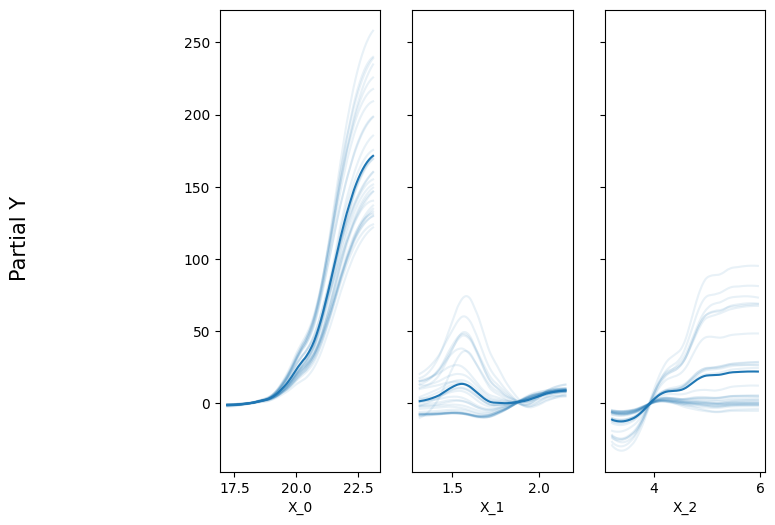

In [8]:
pmb.plot_ice( μ, X, Y, grid=(1, 5), func=np.exp, figsize = (12,6))

In [9]:
vi_penguins = pmb.compute_variable_importance(idata_penguins, μ, X)

<Axes: ylabel='R²'>

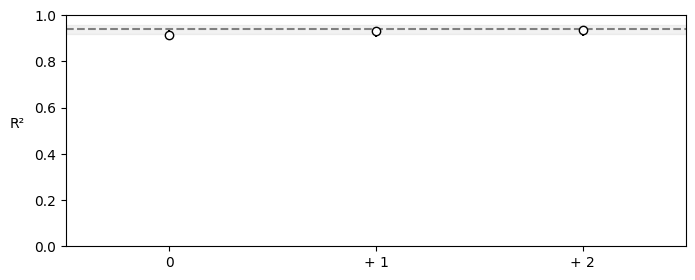

In [11]:
pmb.plot_variable_importance(vi_penguins)

**Task10**:

Using the above plots, make an argument about which variable(s) is/are most important in predicting body mass in penguins.

What is the relationship for each variable to body mass, when you take the other variables into account?

Is that relationship complicated by interactions between variables? How do you know?

Make sure to reference specific things you see in each plot, to justify your decisions and comments.

- flipper length is the most important variable in predicting body mass as the graph came out pretty linear
- flipper length: strong, positive, and linear

  bill depth: weaker but postive

  bill length: basically flat but slighlty positive, very weak

- ICE shows that the variables are not that complicated by interactions